# Phase 4: Forecasting Baseline (ARIMA + TFT Global)

**Goal:** Establish the global forecasting baseline. No regime input. Two models — ARIMA and a Temporal Fusion Transformer — both forecasting next-day S&P 500 returns.

**Splits (sacred):**
- Train: 2000-02-01 → 2017-12-31 (~4,500 days)
- Val:   2018-01-01 → 2020-12-31 (~750 days)
- Test:  2021-01-01 → 2023-12-29 (LOCKED — Phase 6 only)

**Anti-lookahead-bias rules:**
- Macro features (`fed_funds_rate`, `yield_spread`) lagged 1 day
- Models fit on train only; predictions on val are 1-step-ahead with frozen parameters
- Directional accuracy must land in 50–58% range; >60% → audit immediately

## 0. Imports & Config

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from pmdarima import auto_arima

from src.evaluation import compute_metrics

%matplotlib inline
sns.set_theme(style='darkgrid')

DATA_RAW = Path('../data/raw')
FIGURES  = Path('../results/figures')
METRICS  = Path('../results/metrics')
RESULTS  = Path('../results')
FIGURES.mkdir(parents=True, exist_ok=True)
METRICS.mkdir(parents=True, exist_ok=True)

TRAIN_END = '2017-12-31'
VAL_START = '2018-01-01'
VAL_END   = '2020-12-31'
TEST_START = '2021-01-01'

print('Setup complete.')

Setup complete.


## 1. Load Data & Define Splits

In [2]:
df = pd.read_csv(DATA_RAW / 'master.csv', index_col=0, parse_dates=True)
df = df.sort_index()

# DROP test data here for safety — we will only access it in Phase 6
df_phase4 = df.loc[:VAL_END].copy()
print(f'Phase 4 dataset: {df_phase4.shape[0]:,} rows | {df_phase4.index.min().date()} → {df_phase4.index.max().date()}')

train_mask = df_phase4.index <= TRAIN_END
val_mask   = (df_phase4.index >= VAL_START) & (df_phase4.index <= VAL_END)

n_train = train_mask.sum()
n_val   = val_mask.sum()
n_test  = len(df.loc[TEST_START:])
n_total = len(df)

print(f'Train: {n_train:,} ({n_train/n_total*100:.1f}%)')
print(f'Val:   {n_val:,} ({n_val/n_total*100:.1f}%)')
print(f'Test:  {n_test:,} ({n_test/n_total*100:.1f}%) — LOCKED')

y_val_actual = df_phase4.loc[val_mask, 'sp500_return'].values

Phase 4 dataset: 5,264 rows | 2000-02-01 → 2020-12-31
Train: 4,508 (74.9%)
Val:   756 (12.6%)
Test:  753 (12.5%) — LOCKED


## 2. VIZ 4.1 — Train/Val/Test Split Timeline

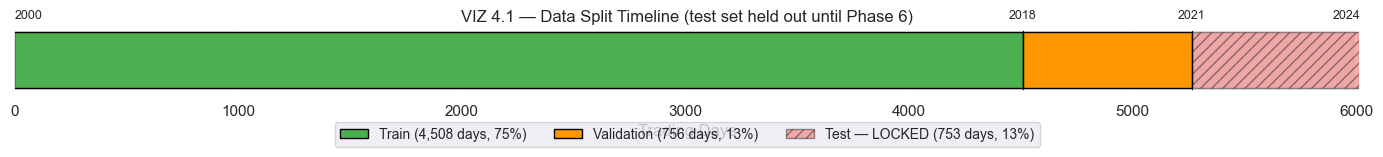

In [3]:
fig, ax = plt.subplots(figsize=(14, 2.5))

ax.barh(0, n_train, color='#4CAF50', edgecolor='black', label=f'Train ({n_train:,} days, {n_train/n_total*100:.0f}%)')
ax.barh(0, n_val, left=n_train, color='#FF9800', edgecolor='black', label=f'Validation ({n_val:,} days, {n_val/n_total*100:.0f}%)')
ax.barh(0, n_test, left=n_train+n_val, color='#F44336', edgecolor='black', alpha=0.4, hatch='///',
        label=f'Test — LOCKED ({n_test:,} days, {n_test/n_total*100:.0f}%)')

ax.set_yticks([])
ax.set_xlabel('Trading Days')
ax.set_title('VIZ 4.1 — Data Split Timeline (test set held out until Phase 6)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=3, fontsize=10)
ax.set_xlim(0, n_total)

# Year labels at split boundaries
ax.axvline(n_train, color='black', linewidth=0.8)
ax.axvline(n_train + n_val, color='black', linewidth=0.8)
ax.text(n_train, 0.6, '2018', ha='center', fontsize=9)
ax.text(n_train + n_val, 0.6, '2021', ha='center', fontsize=9)
ax.text(0, 0.6, '2000', ha='left', fontsize=9)
ax.text(n_total, 0.6, '2024', ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'viz_4_1_data_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. ARIMA Baseline

Fit `auto_arima` on train returns (BIC selection), then apply frozen parameters to the val period via Kalman filter for proper 1-step-ahead predictions (no parameter re-estimation).

In [4]:
train_returns = df_phase4.loc[train_mask, 'sp500_return'].values

print('Fitting auto_arima on train (this takes ~30-60s)...')
arima = auto_arima(
    train_returns,
    seasonal=False,
    information_criterion='bic',
    stepwise=True,
    suppress_warnings=True,
    max_p=5, max_q=5, max_d=2,
    error_action='ignore',
)
print(f'Selected ARIMA order: {arima.order}')
print(f'BIC: {arima.bic():.1f}')

Fitting auto_arima on train (this takes ~30-60s)...


Selected ARIMA order: (0, 0, 2)
BIC: -27011.2


In [5]:
# Apply frozen parameters to the full series, then take 1-step-ahead predictions on val
all_returns = df_phase4['sp500_return'].values

arima_full = sm.tsa.SARIMAX(all_returns, order=arima.order).filter(arima.params())

val_start_idx = int(np.where(val_mask)[0][0])
val_end_idx   = int(np.where(val_mask)[0][-1])

pred = arima_full.get_prediction(start=val_start_idx, end=val_end_idx, dynamic=False)
y_val_arima = pred.predicted_mean

print(f'ARIMA val predictions: {len(y_val_arima)} (expected {n_val})')

metrics_arima = compute_metrics(y_val_actual, y_val_arima)
print(f'ARIMA — MAE={metrics_arima["mae"]:.5f} | RMSE={metrics_arima["rmse"]:.5f} | DirAcc={metrics_arima["dir_acc"]*100:.2f}%')

ARIMA val predictions: 756 (expected 756)
ARIMA — MAE=0.00889 | RMSE=0.01469 | DirAcc=48.54%


### VIZ 4.2 — ARIMA Forecast vs Actual

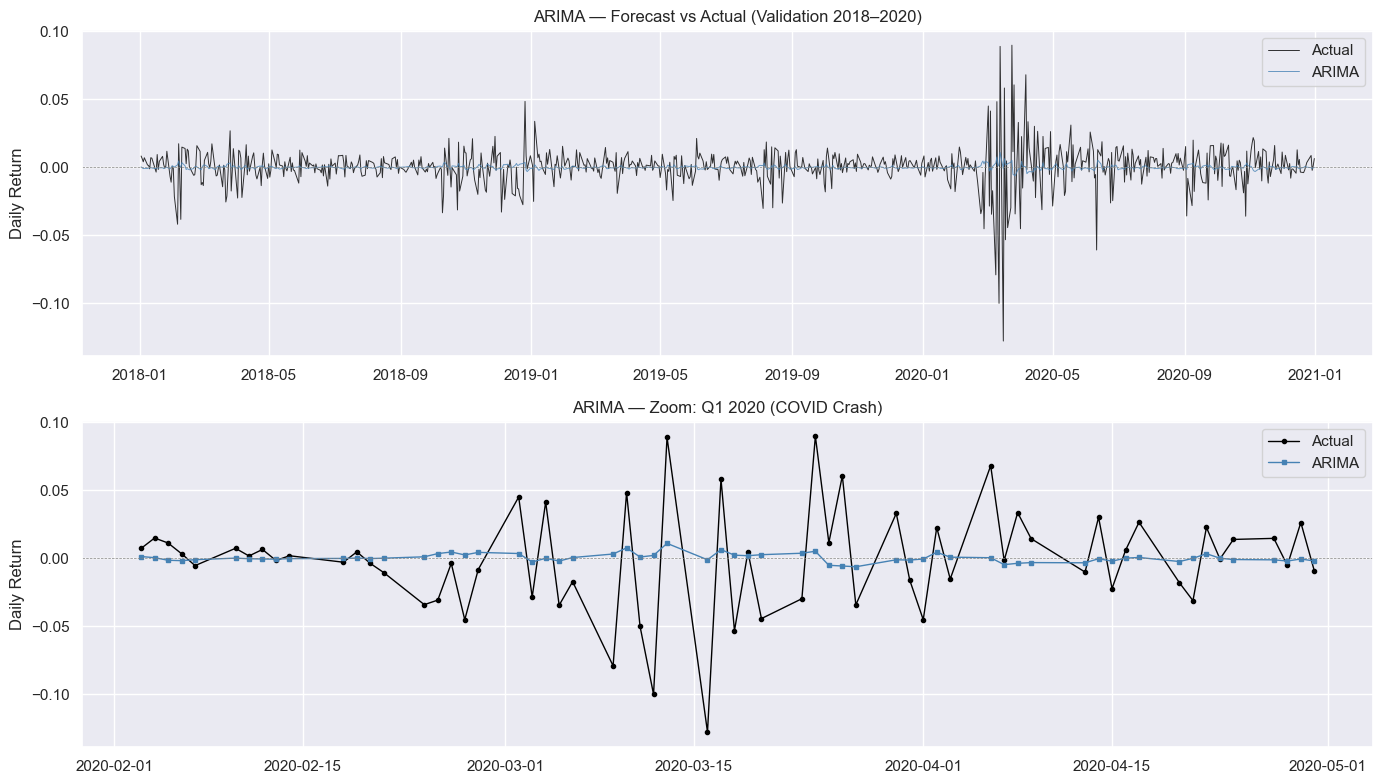

In [6]:
val_dates = df_phase4.index[val_mask]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(val_dates, y_val_actual, color='black', linewidth=0.7, label='Actual', alpha=0.8)
ax.plot(val_dates, y_val_arima,  color='steelblue', linewidth=0.7, label='ARIMA', alpha=0.8)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('ARIMA — Forecast vs Actual (Validation 2018–2020)')
ax.set_ylabel('Daily Return')
ax.legend()

ax = axes[1]
covid_mask = (val_dates >= '2020-02-01') & (val_dates <= '2020-04-30')
ax.plot(val_dates[covid_mask], y_val_actual[covid_mask], color='black', linewidth=1.0, label='Actual', marker='o', markersize=3)
ax.plot(val_dates[covid_mask], y_val_arima[covid_mask],  color='steelblue', linewidth=1.0, label='ARIMA', marker='s', markersize=3)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('ARIMA — Zoom: Q1 2020 (COVID Crash)')
ax.set_ylabel('Daily Return')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / 'viz_4_2_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. TFT Global Baseline

TFT training is run as a standalone script (`scripts/train_tft_global.py`) to avoid Jupyter kernel memory issues on systems with limited RAM. The script saves the trained model checkpoint and validation predictions to `results/`. This notebook cell loads those saved predictions for visualization.

To retrain the TFT, run from project root:
```bash
python scripts/train_tft_global.py
```

In [7]:
# Load TFT predictions saved by scripts/train_tft_global.py
tft_path = RESULTS / 'tft_global_predictions.pkl'
assert tft_path.exists(), (
    f'{tft_path} not found. Run from project root:  python scripts/train_tft_global.py'
)
with open(tft_path, 'rb') as f:
    tft_data = pickle.load(f)

val_dates_tft    = pd.DatetimeIndex(tft_data['val_dates'])
y_val_actual_tft = np.asarray(tft_data['y_actual'])
y_val_tft        = np.asarray(tft_data['y_pred'])
metrics_tft      = tft_data['metrics']

print(f"Loaded TFT predictions: {len(y_val_tft)} rows | trained for {tft_data['stopped_epoch']} epochs")
print(f"TFT Global — MAE={metrics_tft['mae']:.5f} | RMSE={metrics_tft['rmse']:.5f} | DirAcc={metrics_tft['dir_acc']*100:.2f}%")

Loaded TFT predictions: 756 rows | trained for 25 epochs
TFT Global — MAE=0.00888 | RMSE=0.01478 | DirAcc=52.78%


### VIZ 4.3 — TFT Forecast vs Actual + Residuals

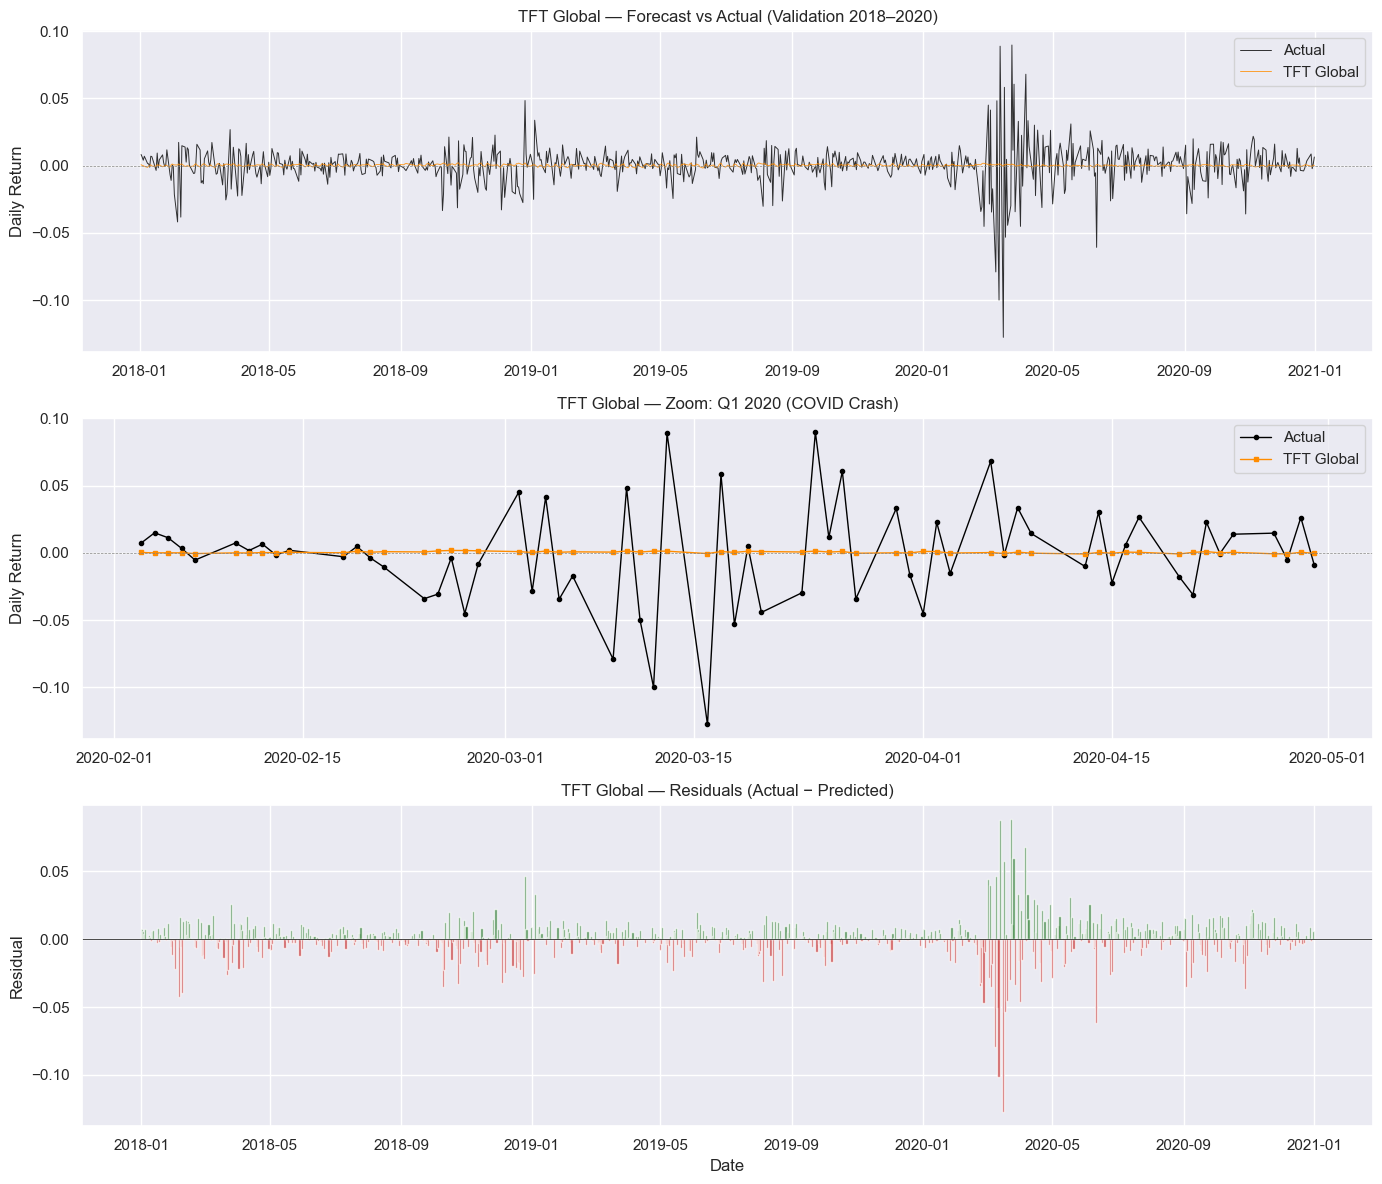

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

ax = axes[0]
ax.plot(val_dates_tft, y_val_actual_tft, color='black', linewidth=0.7, label='Actual', alpha=0.8)
ax.plot(val_dates_tft, y_val_tft,        color='darkorange', linewidth=0.7, label='TFT Global', alpha=0.8)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('TFT Global — Forecast vs Actual (Validation 2018–2020)')
ax.set_ylabel('Daily Return')
ax.legend()

ax = axes[1]
covid_mask_tft = (pd.DatetimeIndex(val_dates_tft) >= '2020-02-01') & (pd.DatetimeIndex(val_dates_tft) <= '2020-04-30')
ax.plot(np.array(val_dates_tft)[covid_mask_tft], y_val_actual_tft[covid_mask_tft],
        color='black', linewidth=1.0, label='Actual', marker='o', markersize=3)
ax.plot(np.array(val_dates_tft)[covid_mask_tft], y_val_tft[covid_mask_tft],
        color='darkorange', linewidth=1.0, label='TFT Global', marker='s', markersize=3)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('TFT Global — Zoom: Q1 2020 (COVID Crash)')
ax.set_ylabel('Daily Return')
ax.legend()

ax = axes[2]
residuals = y_val_actual_tft - y_val_tft
colors = ['#2E7D32' if r >= 0 else '#C62828' for r in residuals]
ax.bar(val_dates_tft, residuals, color=colors, alpha=0.7, width=2)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('TFT Global — Residuals (Actual − Predicted)')
ax.set_ylabel('Residual')
ax.set_xlabel('Date')

plt.tight_layout()
plt.savefig(FIGURES / 'viz_4_3_tft_baseline_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Compare Baselines

### VIZ 4.4 — Baseline Metrics Bar Chart

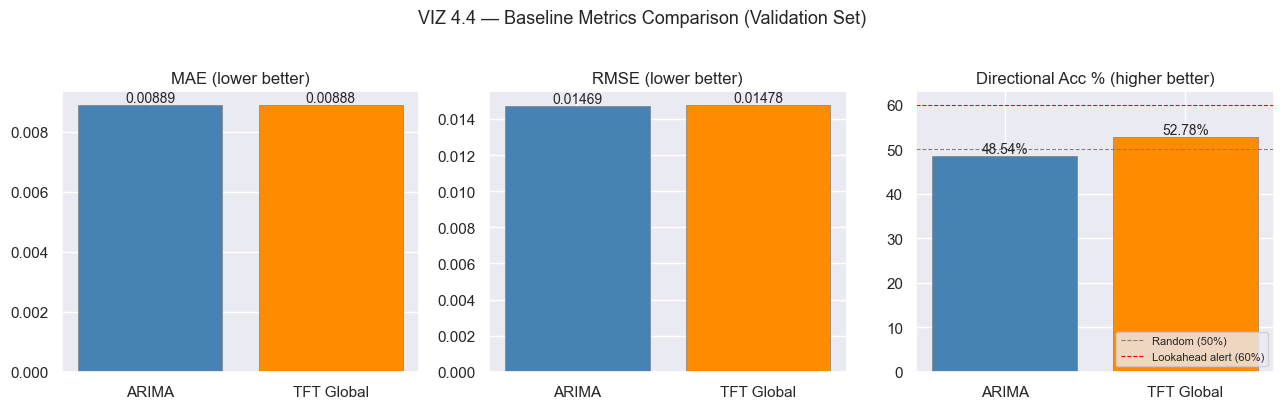

In [9]:
models       = ['ARIMA', 'TFT Global']
model_colors = ['steelblue', 'darkorange']
metrics_list = [metrics_arima, metrics_tft]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('VIZ 4.4 — Baseline Metrics Comparison (Validation Set)', fontsize=13, y=1.02)

for ax, key, title, fmt in zip(axes,
                                 ['mae', 'rmse', 'dir_acc'],
                                 ['MAE (lower better)', 'RMSE (lower better)', 'Directional Acc % (higher better)'],
                                 ['{:.5f}', '{:.5f}', '{:.2f}%']):
    vals = [m[key] * (100 if key == 'dir_acc' else 1) for m in metrics_list]
    bars = ax.bar(models, vals, color=model_colors, edgecolor='gray', linewidth=0.5)
    ax.set_title(title)
    if key == 'dir_acc':
        ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='Random (50%)')
        ax.axhline(60, color='red',  linestyle='--', linewidth=0.8, label='Lookahead alert (60%)')
        ax.legend(fontsize=8, loc='lower right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt.format(v),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES / 'viz_4_4_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Save metrics CSV
metrics_df = pd.DataFrame({
    'model': models,
    'mae':     [m['mae']     for m in metrics_list],
    'rmse':    [m['rmse']    for m in metrics_list],
    'dir_acc': [m['dir_acc'] for m in metrics_list],
})
metrics_df.to_csv(METRICS / 'phase4_baselines.csv', index=False)
print(f'Saved {METRICS / "phase4_baselines.csv"}')
print()
print(metrics_df.to_string(index=False))

Saved ../results/metrics/phase4_baselines.csv

     model      mae     rmse  dir_acc
     ARIMA 0.008891 0.014692 0.485450
TFT Global 0.008883 0.014783 0.527778


## 6. Phase 4 Gate Checks

In [11]:
# Gate: directional accuracy in safe range — alert if >60% (lookahead bias)
for m, name in [(metrics_arima, 'ARIMA'), (metrics_tft, 'TFT Global')]:
    assert m['dir_acc'] < 0.60, f'FAIL: {name} dir_acc={m["dir_acc"]:.3f} >= 0.60 — possible lookahead bias'
    assert m['dir_acc'] > 0.40, f'FAIL: {name} dir_acc={m["dir_acc"]:.3f} <= 0.40 — model worse than random'

# Gate: MAE in plausible range
for m, name in [(metrics_arima, 'ARIMA'), (metrics_tft, 'TFT Global')]:
    assert 0.001 < m['mae'] < 0.05, f'FAIL: {name} MAE={m["mae"]:.5f} outside plausible range'

# Gate: all 4 figures saved
for fname in ['viz_4_1_data_split.png', 'viz_4_2_arima_forecast.png',
              'viz_4_3_tft_baseline_forecast.png', 'viz_4_4_baseline_comparison.png']:
    assert (FIGURES / fname).exists(), f'FAIL: {fname} not found'

# Gate: metrics CSV saved
assert (METRICS / 'phase4_baselines.csv').exists()

# Gate: TFT artifacts saved
assert (RESULTS / 'tft_global.ckpt').exists()
assert (RESULTS / 'tft_global_predictions.pkl').exists()

print('All Phase 4 gate checks PASSED.')
print()
print(f'ARIMA      — MAE={metrics_arima["mae"]:.5f} | RMSE={metrics_arima["rmse"]:.5f} | DirAcc={metrics_arima["dir_acc"]*100:.2f}%')
print(f'TFT Global — MAE={metrics_tft["mae"]:.5f} | RMSE={metrics_tft["rmse"]:.5f} | DirAcc={metrics_tft["dir_acc"]*100:.2f}%')

winner_mae = 'TFT Global' if metrics_tft['mae'] < metrics_arima['mae'] else 'ARIMA'
winner_dir = 'TFT Global' if metrics_tft['dir_acc'] > metrics_arima['dir_acc'] else 'ARIMA'
print(f'\nMAE winner:    {winner_mae}')
print(f'DirAcc winner: {winner_dir}')

All Phase 4 gate checks PASSED.

ARIMA      — MAE=0.00889 | RMSE=0.01469 | DirAcc=48.54%
TFT Global — MAE=0.00888 | RMSE=0.01478 | DirAcc=52.78%

MAE winner:    TFT Global
DirAcc winner: TFT Global
